## Classification after Clustering

**Importing required packages and csv**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
pd.set_option("display.max_columns", None)
df = pd.read_csv("./data/clustered_data.csv")
print(df.shape)

(2240, 21)


**Split X and y**
- Why do we split our data?
> Training Dataset is the part of Original Dataset that we use to train our ML model. The model learns on this data by running the algorithm and maps a function F(x) where “x” in the independent variable (inputs) for “y” where “y” is the dependent variable(output).

In [3]:
X = df.drop("cluster", axis=1)
y = df["cluster"]

## Grid Search

- Why do we use Grid Search?

`GridSearchCV` is a technique to search through the best parameter values from the given set of the grid of parameters. It is basically a cross-validation method. the model and the parameters are required to be feed in. Best parameter values are extracted and then the predictions are made.

## Select the best model
- So, Here we have some list of the best classification algorithms we imported. Now we will compare each model's score and see which model is performing better.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

from sklearn.model_selection import train_test_split, cross_val_score

In [5]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
    "CatBoost Classifier": CatBoostClassifier(verbose=False),
    "AdaBoost Classifier": AdaBoostClassifier()
}

### We will create a generic function to check each model's performance and to compare them

In [6]:
def evaluate_models(X, y, models):
    '''
    This function takes in X, y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''

    # Seprate dataset into train, test
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

    models_list=[]
    scores=[]

    for i in range(len(list(models))):
        model = list(models.values())[i]
        # Train model
        model.fit(X_train, y_train)

        # Make Prediction
        y_pred = model.predict(X_test)
        score = accuracy_score(y_test, y_pred)

        model_name = list(models.keys())[i]
        print(f"Score for {model_name}: {score}")
        print(f"-----------------------------------------------")

        models_list.append(model_name)
        scores.append(score)

    print()
    df = pd.DataFrame()
    df["Model_Name"] = models_list
    df["Score"] = scores
    return df

In [7]:
help(evaluate_models)

Help on function evaluate_models in module __main__:

evaluate_models(X, y, models)
    This function takes in X, y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost



In [8]:
# Check the report
report = evaluate_models(X,y,models)

Score for Random Forest: 0.9553571428571429
-----------------------------------------------
Score for Decision Tree: 0.9464285714285714
-----------------------------------------------
Score for Gradient Boosting: 0.9642857142857143
-----------------------------------------------
Score for Logistic Regression: 0.8683035714285714
-----------------------------------------------
Score for K-Neighbors Classifier: 0.7991071428571429
-----------------------------------------------
Score for XGBClassifier: 0.9665178571428571
-----------------------------------------------
Score for CatBoost Classifier: 0.9709821428571429
-----------------------------------------------
Score for AdaBoost Classifier: 0.9397321428571429
-----------------------------------------------



In [9]:
report.sort_values("Score", ascending=False)

,Model_Name,Score
6,CatBoost Classifier,0.970982
5,XGBClassifier,0.966518
2,Gradient Boosting,0.964286
0,Random Forest,0.955357
1,Decision Tree,0.946429
7,AdaBoost Classifier,0.939732
3,Logistic Regression,0.868304
4,K-Neighbors Classifier,0.799107


##### From the report above we can see that the CatBoost, XGBoost, Gradient Boosting, Random Forest are the models which performed well. So, we will continue training our model using XGBoost Classifier algorithm.

### Split into Train and test data

**Do you know why we split the train and test dataset?**
> The train test split technique can be used for classification and regression problems to test machine learning algorithms. The procedure takes the given dataset and splits it into two subsets:

>```Training data/train set:``` It is used to train the algorithm and fit the machine learning model

>```test data/test set:``` It is basically a different data for which we know the values but this data was never shown to the model before. Thus if the model after training is performing good on test set as well then we can say that the Machine Learning model is good.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1792, 20), (1792,), (448, 20), (448,))

### Hyperparameter tuning

> A Machine Learning model is defined as a mathematical model with a number of parameters that need to be learned from the data. By training a model with existing data, we are able to fit the model parameters.

> However, there is another kind of parameter, known as Hyperparameters, that cannot be directly learned from the regular training process. They are usually fixed before the actual training process begins. These parameters express important properties of the model such as its complexity or how fast it should learn.

In [11]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [12]:
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [13]:
xgb_cv = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    refit=True
)

In [14]:
xgb_cv.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


* We got the best model. So, now predict on the X_test data.

In [15]:
best_model = xgb_cv.best_estimator_
best_model

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [16]:
y_pred = best_model.predict(X_test)

score = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

* Let's check `Report` now:

In [17]:
print("Best Parameters:", xgb_cv.best_params_)
print("Best Cross Validation Score:", xgb_cv.best_score_)
print(f"Test Accuracy: {score:.4f}")
print(cr)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best Cross Validation Score: 0.9687368699522262
Test Accuracy: 0.9732
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       167
           1       0.99      0.95      0.97       129
           2       0.94      0.99      0.96       152

    accuracy                           0.97       448
   macro avg       0.97      0.97      0.97       448
weighted avg       0.97      0.97      0.97       448



## Confusion matrix of the model
- **What is confusion matrix ?**
> The confusion matrix is a matrix used to determine the performance of the classification models for a given set of test data. It can only be determined if the true values for test data are known. The matrix itself can be easily understood, but the related terminologies may be confusing.

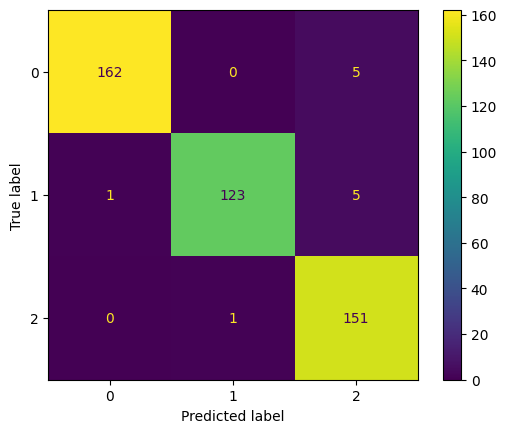

In [18]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

In [19]:
import pickle

# File path where the model should be saved
model_path = "model.pkl"

# Save the model as .pkl file
with open(model_path, "wb") as model_file:
    pickle.dump(best_model, model_file)

print(f"Model saved successfully at {model_path}")

Model saved successfully at model.pkl


- **Reports**

**We can see, that the model performed pretty well.**
- we have used XGBClassifier as it performed well than other models
- We got a good accuracy while predicting the test dataset.